# TP8c — Early Stopping

Dans TP8b, B8 atteint `PR-AUC train = 1.0000` avec `n_estimators=382` — signe de mémorisation du train set.

Ce notebook applique l'**early stopping** : le modèle s'arrête dès que le val set cesse de s'améliorer,
sans avoir à fixer `n_estimators` à l'avance.

| Modèle | n_estimators | PR-AUC val | PR-AUC test | Overfitting Δ |
|--------|-------------|------------|-------------|---------------|
| B8 (TP8b) | 382 (fixe) | 0.8497 | 0.8232 | 0.1503 |
| **B8-ES** | ? (auto) | ? | ? | ? |

## 1. Imports

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sqlalchemy import create_engine
from sqlalchemy.engine import URL
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score, roc_auc_score, f1_score,
    precision_recall_curve
)
from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Imports OK")

Imports OK


## 2. Données — même configuration que TP8b

In [3]:
url = URL.create(
    drivername="postgresql+psycopg2",
    username="indusense_user",
    password="ThEP@ssW0rd",
    host="localhost", port=5432, database="indusense_db",
)
engine = create_engine(url)
df = pd.read_sql(
    "SELECT * FROM gold_machine_hourly_feature ORDER BY machine_id, window_start",
    engine
)

TARGET = "label_failure_next_24h"
LEAKAGE_COLS = [
    "machine_id", "ingestion_batch_id", "window_start", "window_end", "split_set",
    "label_failure_next_6h", "label_failure_next_12h", "label_failure_next_48h",
    TARGET, "feature_row_id",
]
FEATURE_COLS = [c for c in df.columns if c not in LEAKAGE_COLS]

train_df = df[df["split_set"] == "train"].copy()
val_df   = df[df["split_set"] == "validation"].copy()
test_df  = df[df["split_set"] == "test"].copy()

X_train, y_train = train_df[FEATURE_COLS], train_df[TARGET]
X_val,   y_val   = val_df[FEATURE_COLS],   val_df[TARGET]
X_test,  y_test  = test_df[FEATURE_COLS],  test_df[TARGET]

SPW = round((y_train == 0).sum() / (y_train == 1).sum(), 2)
print(f"Dataset : {df.shape[0]:,} lignes | Features : {len(FEATURE_COLS)}")
print(f"Train : {len(X_train):,} | Val : {len(X_val):,} | Test : {len(X_test):,}")
print(f"scale_pos_weight = {SPW}")

Dataset : 132,940 lignes | Features : 69
Train : 93,079 | Val : 19,917 | Test : 19,944
scale_pos_weight = 26.78


## 3. Imputation séparée

L'early stopping nécessite de passer `eval_set` au `fit()` avec des données déjà imputées.
On sépare donc l'imputer du modèle (pas de Pipeline cette fois).

In [4]:
# Fit sur train uniquement — transform appliqué à val et test
imputer = SimpleImputer(strategy="median").fit(X_train)
X_train_imp = imputer.transform(X_train)
X_val_imp   = imputer.transform(X_val)
X_test_imp  = imputer.transform(X_test)

print(f"Imputation OK — shapes : train={X_train_imp.shape}, val={X_val_imp.shape}")

Imputation OK — shapes : train=(93079, 67), val=(19917, 67)


## 4. B8-ES — Early stopping avec les meilleurs params B8

On reprend les hyperparamètres trouvés par Optuna dans TP8b,
mais `n_estimators` devient une borne haute (1 000) et `early_stopping_rounds=30`
arrête l'entraînement si le PR-AUC val ne s'améliore pas sur 30 arbres consécutifs.

In [5]:
# Hyperparamètres B8 (Optuna TP8b) — n_estimators remplacé par une borne haute
B8_PARAMS = {
    "max_depth":         8,
    "learning_rate":     0.19367782999811112,
    "subsample":         0.9870283480802571,
    "colsample_bytree":  0.8035421212629575,
    "min_child_weight":  6,
    "reg_alpha":         0.0014393622771964793,
    "reg_lambda":        0.00014158997638181163,
    "scale_pos_weight":  SPW,
    "random_state":      RANDOM_STATE,
    "verbosity":         0,
    # Early stopping
    "n_estimators":      1000,          # borne haute
    "early_stopping_rounds": 30,        # stop si pas de progrès sur 30 arbres
    "eval_metric":       "aucpr",
}

model_es = XGBClassifier(**B8_PARAMS)
model_es.fit(
    X_train_imp, y_train,
    eval_set=[(X_val_imp, y_val)],      # surveillé à chaque arbre
    verbose=False,
)

print(f"Entraînement terminé")
print(f"  Arbres utilisés   : {model_es.best_iteration + 1} / 1000")
print(f"  Meilleur PR-AUC val (early stopping) : {model_es.best_score:.4f}")

Entraînement terminé
  Arbres utilisés   : 57 / 1000
  Meilleur PR-AUC val (early stopping) : 0.8469


## 5. Évaluation B8-ES

In [6]:
def score(model, X, y, label):
    yp = model.predict_proba(X)[:, 1]
    pr = average_precision_score(y, yp)
    ro = roc_auc_score(y, yp)
    f1 = f1_score(y, model.predict(X), zero_division=0)
    print(f"[{label}] PR-AUC={pr:.4f} | ROC-AUC={ro:.4f} | F1={f1:.4f}")
    return {"pr": pr, "roc": ro, "f1": f1}

s_train = score(model_es, X_train_imp, y_train, "B8-ES train")
s_val   = score(model_es, X_val_imp,   y_val,   "B8-ES val  ")
s_test  = score(model_es, X_test_imp,  y_test,  "B8-ES test ")

delta_tv = round(s_train["pr"] - s_val["pr"], 4)
print(f"\nOverfitting Δ train-val : {delta_tv:.4f}")
flag = "⚠️" if delta_tv > 0.10 else "✅"
print(f"{flag} {'Overfitting réduit' if delta_tv < 0.1503 else 'Overfitting persistant'}")

print("\n=== Comparaison B8 vs B8-ES ===")
print(f"  {'Modèle':<12} {'n_trees':>8} {'PR-AUC val':>12} {'PR-AUC test':>13} {'Δ overfitting':>15}")
print("  " + "-"*65)
print(f"  {'B8':<12} {'382':>8} {'0.8497':>12} {'0.8232':>13} {'0.1503':>15}")
print(f"  {'B8-ES':<12} {str(model_es.best_iteration+1):>8} {s_val['pr']:>12.4f} {s_test['pr']:>13.4f} {delta_tv:>15.4f}")

[B8-ES train] PR-AUC=1.0000 | ROC-AUC=1.0000 | F1=0.9737
[B8-ES val  ] PR-AUC=0.8471 | ROC-AUC=0.9940 | F1=0.7571
[B8-ES test ] PR-AUC=0.7968 | ROC-AUC=0.9926 | F1=0.7386

Overfitting Δ train-val : 0.1529
⚠️ Overfitting persistant

=== Comparaison B8 vs B8-ES ===
  Modèle        n_trees   PR-AUC val   PR-AUC test   Δ overfitting
  -----------------------------------------------------------------
  B8                382       0.8497        0.8232          0.1503
  B8-ES              57       0.8471        0.7968          0.1529


## 6. Courbe de convergence — val PR-AUC par arbre

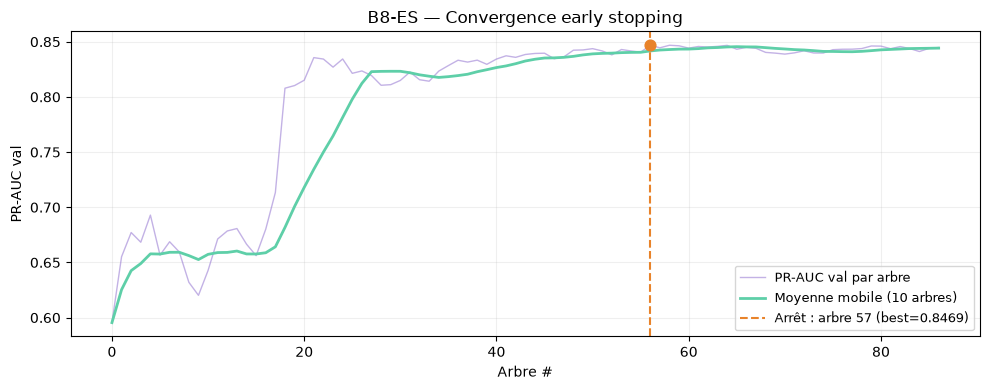

Plateau atteint après l'arbre 57 — 1000 - 57 = 943 arbres économisés


In [7]:
evals = model_es.evals_result()
val_scores = evals["validation_0"]["aucpr"]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(val_scores, color="#9B7FD4", linewidth=1, alpha=0.6, label="PR-AUC val par arbre")

# Lissage
window = 10
smoothed = pd.Series(val_scores).rolling(window, min_periods=1).mean()
ax.plot(smoothed, color="#5ECFA8", linewidth=2, label=f"Moyenne mobile ({window} arbres)")

# Best iteration
best_i = model_es.best_iteration
ax.axvline(best_i, color="#E8832A", linestyle="--", linewidth=1.5,
           label=f"Arrêt : arbre {best_i+1} (best={val_scores[best_i]:.4f})")
ax.scatter([best_i], [val_scores[best_i]], color="#E8832A", zorder=5, s=60)

ax.set_xlabel("Arbre #")
ax.set_ylabel("PR-AUC val")
ax.set_title("B8-ES — Convergence early stopping")
ax.legend(fontsize=9)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("b8es_convergence.png", dpi=150)
plt.show()
print(f"Plateau atteint après l'arbre {best_i+1} — 1000 - {best_i+1} = {1000 - best_i - 1} arbres économisés")